#### Loading cleaned datasets

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ECB API data
df = pd.read_csv('inflation_clean.csv')

# Eurostat API
df2 = pd.read_csv('interest_clean.csv')

# Energy clean
df3 = pd.read_csv('energy_clean.csv')

# Energy_clean_index
df4 = pd.read_csv('energy_clean_index.csv')

df.head(25)

,date,country,inflation
0,2015-01,DE,-0.5
1,2015-02,DE,-0.2
2,2015-03,DE,0.3
3,2015-04,DE,1.0
4,2015-05,DE,1.6
5,2015-06,DE,1.1
6,2015-07,DE,1.3
7,2015-08,DE,1.1
8,2015-09,DE,0.8
9,2015-10,DE,1.2


In [2]:
df2.head()

,date,interest
0,2015-12,-0.30
1,2016-03,-0.40
2,2019-09,-0.50
3,2022-07,0.00
4,2022-09,0.75


In [3]:
df3.head(5)

,country,date,energy
0,DE,2014-07,0.248944
1,DE,2014-08,0.248793
2,DE,2014-09,0.248641
3,DE,2014-10,0.248489
4,DE,2014-11,0.248337


In [4]:
df4.head(4)

,date,country,energy_price_index
0,2015-01-01,DE,100.5
1,2015-02-01,DE,101.9
2,2015-03-01,DE,101.9
3,2015-04-01,DE,101.5


---

In [5]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df2["date"] = pd.to_datetime(df2["date"], errors="coerce")

In [6]:
df2["interest"] = pd.to_numeric(df2["interest"], errors="coerce")

# Keep only what we need
df2 = df2[["date", "interest"]]

# Remove the duplicates
df2 = df2.drop_duplicates(subset=["date"])
df = df.drop_duplicates(subset=["country", "date"])


### Merging (inflation and interest) the datasets via date
---

In [7]:
# Making sure the date format matches each dataset
df['date'] = pd.to_datetime(df['date']).dt.to_period('M').astype(str)
df2['date'] = pd.to_datetime(df2['date']).dt.to_period('M').astype(str)

In [8]:
# Merge the two datsets
df_merged = pd.merge(df,df2, on='date', how='left')

# Sort the values
df_merged = df_merged.sort_values(['country', 'date'])

In [9]:
df_merged

,date,country,inflation,interest
0,2015-01,DE,-0.5,NaN
1,2015-02,DE,-0.2,NaN
2,2015-03,DE,0.3,NaN
3,2015-04,DE,1.0,NaN
4,2015-05,DE,1.6,NaN
...,...,...,...,...
427,2023-08,IT,5.5,3.75
428,2023-09,IT,5.6,4.00
429,2023-10,IT,1.8,NaN
430,2023-11,IT,0.6,NaN


In [10]:
# Filling in the Nan values
df_merged = df_merged.sort_values(["country", "date"])

df_merged["interest"] = df_merged["interest"].ffill().bfill()

In [11]:
df_merged["date"] = pd.to_datetime(df_merged["date"]).dt.to_period("M")


In [12]:
df_merged.tail()

,date,country,inflation,interest
427,2023-08,IT,5.5,3.75
428,2023-09,IT,5.6,4.00
429,2023-10,IT,1.8,4.00
430,2023-11,IT,0.6,4.00
431,2023-12,IT,0.5,4.00


In [13]:
df_merged.shape

(432, 4)

In [14]:
df_merged['country'].unique()

array(['DE', 'ES', 'FR', 'IT'], dtype=object)

In [15]:
print(df_merged[df_merged["inflation"].isna()].head(20))

Empty DataFrame
Columns: [date, country, inflation, interest]
Index: []


In [16]:
df_merged.head(5)

,date,country,inflation,interest
0,2015-01,DE,-0.5,-0.3
1,2015-02,DE,-0.2,-0.3
2,2015-03,DE,0.3,-0.3
3,2015-04,DE,1.0,-0.3
4,2015-05,DE,1.6,-0.3


#### Merge (energy_clean and energy_clean) index
---

In [17]:
df3.head()

,country,date,energy
0,DE,2014-07,0.248944
1,DE,2014-08,0.248793
2,DE,2014-09,0.248641
3,DE,2014-10,0.248489
4,DE,2014-11,0.248337


In [18]:
df4.head()

,date,country,energy_price_index
0,2015-01-01,DE,100.5
1,2015-02-01,DE,101.9
2,2015-03-01,DE,101.9
3,2015-04-01,DE,101.5
4,2015-05-01,DE,101.8


In [19]:
# Fixing date columns -- make sure they are the same
df3["date"] = pd.to_datetime(df3["date"]).dt.to_period("M")
df4["date"] = pd.to_datetime(df4["date"]).dt.to_period("M")


In [20]:
df_energy = pd.merge(df3, df4, on=['date', 'country'], how='inner')

In [21]:
df_energy

,country,date,energy,energy_price_index
0,DE,2015-01,0.248033,100.5
1,DE,2015-02,0.247959,101.9
2,DE,2015-03,0.247884,101.9
3,DE,2015-04,0.247810,101.5
4,DE,2015-05,0.247736,101.8
...,...,...,...,...
427,IT,2023-08,0.327449,175.2
428,IT,2023-09,0.329129,175.6
429,IT,2023-10,0.330809,176.8
430,IT,2023-11,0.332489,173.1


### Merge to create final dataframe
---

In [22]:
final_df = pd.merge(df_merged,df_energy, on=["date", "country"], how="inner")

In [23]:
final_df.head()

,date,country,inflation,interest,energy,energy_price_index
0,2015-01,DE,-0.5,-0.3,0.248033,100.5
1,2015-02,DE,-0.2,-0.3,0.247959,101.9
2,2015-03,DE,0.3,-0.3,0.247884,101.9
3,2015-04,DE,1.0,-0.3,0.247810,101.5
4,2015-05,DE,1.6,-0.3,0.247736,101.8


In [24]:
final_df.shape

(432, 6)

In [25]:
final_df["date"].min(), final_df["date"].max()

(Period('2015-01', 'M'), Period('2023-12', 'M'))

In [26]:
final_df.isna().sum()

date                  0
country               0
inflation             0
interest              0
energy                0
energy_price_index    0
dtype: int64

In [27]:
final_df.duplicated().sum()

np.int64(0)

In [28]:
# Final check for date range
final_df['date'].min(), final_df['date'].max()

(Period('2015-01', 'M'), Period('2023-12', 'M'))

In [29]:
# Add column for Green deal with a function

def classify_time(date):
  if date < pd.Period('2018-01', freq='M'):
    return 'Pre Green Deal'
  elif date < pd.Period('2021-01', freq='M'):
    return 'Green Deal'
  else:
    return 'In Energy Crisis'

final_df['green_deal_time'] = final_df['date'].apply(classify_time)

final_df.head(5)

,date,country,inflation,interest,energy,energy_price_index,green_deal_time
0,2015-01,DE,-0.5,-0.3,0.248033,100.5,Pre Green Deal
1,2015-02,DE,-0.2,-0.3,0.247959,101.9,Pre Green Deal
2,2015-03,DE,0.3,-0.3,0.247884,101.9,Pre Green Deal
3,2015-04,DE,1.0,-0.3,0.247810,101.5,Pre Green Deal
4,2015-05,DE,1.6,-0.3,0.247736,101.8,Pre Green Deal


In [30]:
final_df['green_deal_time'].unique()

array(['Pre Green Deal', 'Green Deal', 'In Energy Crisis'], dtype=object)

In [31]:
final_df[['date', 'green_deal_time']].head()

,date,green_deal_time
0,2015-01,Pre Green Deal
1,2015-02,Pre Green Deal
2,2015-03,Pre Green Deal
3,2015-04,Pre Green Deal
4,2015-05,Pre Green Deal


#### Visuals
 ---- 

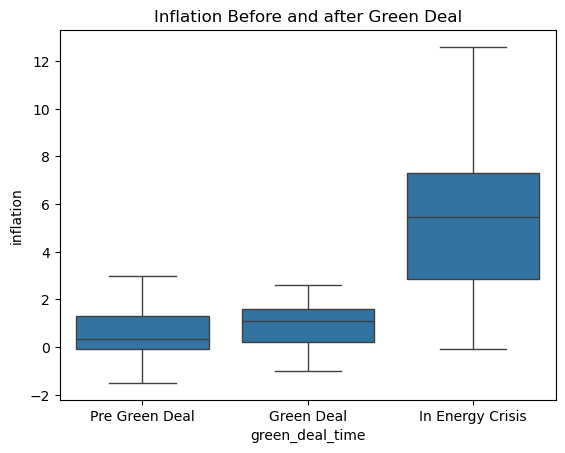

In [32]:
sns.boxplot(data=final_df, x = 'green_deal_time', y='inflation')
plt.title('Inflation Before and after Green Deal')
plt.show()

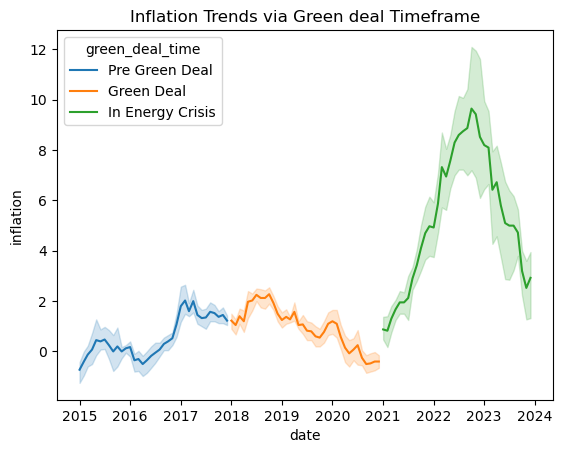

In [33]:
df_visual = final_df.copy()
df_visual['date'] = df_visual['date'].dt.to_timestamp()

sns.lineplot(data=df_visual, x='date', y='inflation', hue='green_deal_time')
plt.title('Inflation Trends via Green deal Timeframe')
plt.show()

## H3: Does the relationship between energy prices and inflation vary across countries?

<Axes: xlabel='energy_price_index', ylabel='inflation'>

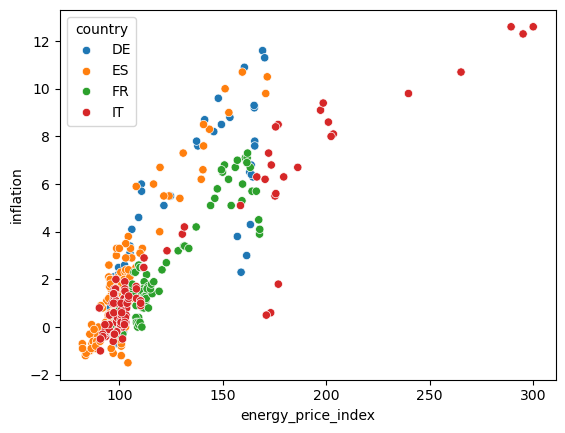

In [38]:
import seaborn as sns

sns.scatterplot(
    data=final_df,
    x="energy_price_index",
    y="inflation",
    hue="country"
)